# 02 — ERP Extraction
Loads epochs, extracts N170/VPP/P300 amplitudes

In [1]:
import numpy as np, os, os.path as op, matplotlib.pyplot as plt
import mne; mne.set_log_level("WARNING")
import warnings; warnings.filterwarnings('ignore')
import importlib.util
spec = importlib.util.spec_from_file_location("cfg", "00_config.py")
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)
for a in dir(cfg):
    if not a.startswith('_'): globals()[a] = getattr(cfg, a)

all_subjs = np.load(CKPT['subjects'], allow_pickle=True).tolist()

def load_ep(sub):
    return mne.read_epochs(op.join(CHECKPOINT_DIR, 'epochs', f'{sub}-epo.fif'), verbose=False)

def erp_amp(epochs, channels, tmin, tmax, polarity):
    avail = [c for c in channels if c in epochs.ch_names]
    if not avail: return np.nan, np.nan, np.nan
    evk = epochs.average().pick_channels(avail)
    d = evk.data * 1e6; t = evk.times
    i1,i2 = np.argmin(np.abs(t-tmin)), np.argmin(np.abs(t-tmax))
    win = d[:, i1:i2]
    avg = np.mean(win, axis=0)
    pidx = np.argmin(avg) if polarity=='negative' else np.argmax(avg)
    return np.mean(win), avg[pidx], t[i1+pidx]*1000

In [2]:
results = []
for sub in all_subjs:
    ep = load_ep(sub)
    for cond, label in [('target','Target'),('nontarget','Non-target')]:
        keys = [k for k in ep.event_id if cond in k and ('nontarget' in k)==(cond=='nontarget')]
        if not keys: continue
        row = {'subject':sub, 'condition':label, 'n':len(ep[keys])}
        for comp, info in ERP_COMPONENTS.items():
            m,p,l = erp_amp(ep[keys], info['channels'], info['tmin'], info['tmax'], info['polarity'])
            row[f'{comp}_mean'] = m; row[f'{comp}_peak'] = p; row[f'{comp}_lat'] = l
        results.append(row)
    del ep

np.savez(CKPT['erp_results'], erp_results=results)

print(f"{'Sub':<8} {'Cond':<10} {'N':>3} {'P300':>7} {'N170':>7} {'VPP':>7}")
for r in results:
    print(f"{r['subject']:<8} {r['condition']:<10} {r['n']:>3} {r['P300_mean']:>7.2f} {r['N170_mean']:>7.2f} {r['VPP_mean']:>7.2f}")

Sub      Cond         N    P300    N170     VPP
sub-010  Target      60    8.34   -5.22    4.93
sub-010  Non-target 300   -0.35    0.41    0.20
sub-011  Target      60    0.63   -2.70    1.07
sub-011  Non-target 300   -0.28    0.43   -0.21
sub-012  Target      60    1.88   -3.53    2.61
sub-012  Non-target 300   -0.33   -0.41    0.64
sub-013  Target      60    4.09   -3.22    2.57
sub-013  Non-target 300   -0.04   -0.04    0.26
sub-014  Target      60    4.97   -2.94    2.81
sub-014  Non-target 300    0.35    1.91   -1.19
sub-015  Target      60    5.80   -2.45    1.18
sub-015  Non-target 300   -0.40    1.54   -1.04
sub-016  Target      60    5.42   -2.22    1.45
sub-016  Non-target 300    0.13    1.21   -0.66
sub-019  Target      60    3.84    0.35    0.51
sub-019  Non-target 300    0.26    0.05    0.35
sub-020  Target      60    4.65    1.12   -1.82
sub-020  Non-target 300   -0.30    0.57   -0.43
sub-021  Target      60    3.40   -0.52   -0.58
sub-021  Non-target 300    0.30    0.26 

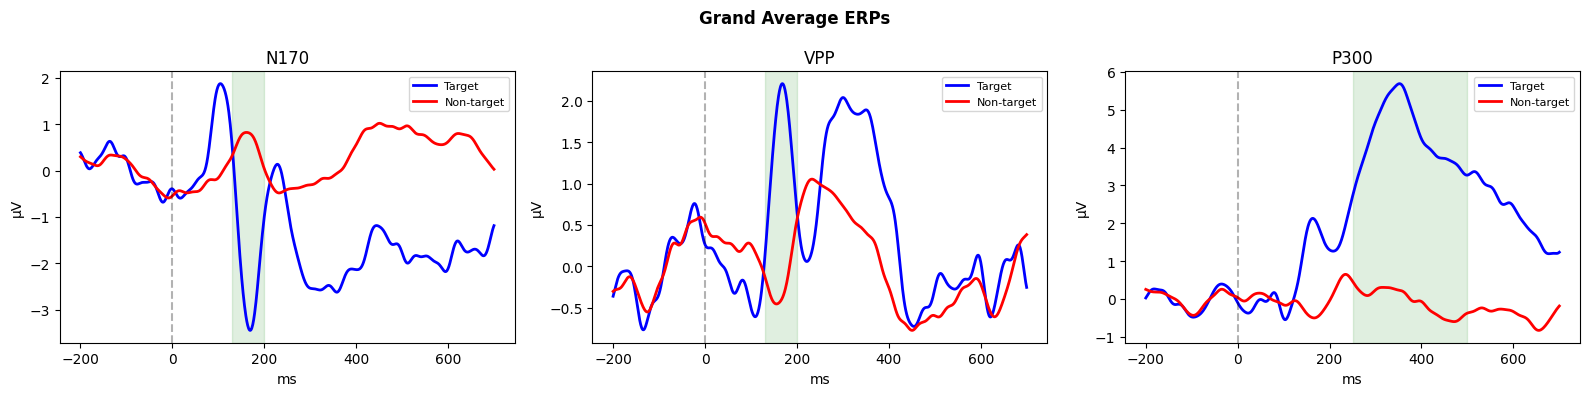

In [3]:
# grand average plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, info) in zip(axes, ERP_COMPONENTS.items()):
    chs = info['channels']
    tgt, ntgt = [], []
    for sub in all_subjs:
        ep = load_ep(sub)
        tk = [k for k in ep.event_id if 'target' in k and 'nontarget' not in k]
        nk = [k for k in ep.event_id if 'nontarget' in k]
        av = [c for c in chs if c in ep.ch_names]
        if tk and av: tgt.append(ep[tk].average().pick_channels(av))
        if nk and av: ntgt.append(ep[nk].average().pick_channels(av))
        del ep
    if tgt:
        ga_t = mne.grand_average(tgt); ga_n = mne.grand_average(ntgt)
        t = ga_t.times*1000
        ax.plot(t, np.mean(ga_t.data*1e6,axis=0), 'b-', lw=2, label='Target')
        ax.plot(t, np.mean(ga_n.data*1e6,axis=0), 'r-', lw=2, label='Non-target')
        ax.axvspan(info['tmin']*1e3, info['tmax']*1e3, alpha=0.12, color='green')
        ax.axvline(0, color='k', ls='--', alpha=0.3)
        ax.set_xlabel('ms'); ax.set_ylabel('µV'); ax.set_title(name); ax.legend(fontsize=8)
fig.suptitle('Grand Average ERPs', fontweight='bold')
plt.tight_layout(); plt.show()